# Prediccion de resultados del futbol uruguayo: arbol ID3

Este notebook entrena un arbol de decision **ID3** propio (implementado en `src/id3.py`) para predecir el resultado de un partido (`L` local, `E` empate, `V` visitante).

A diferencia de un experimento "caja negra", aca se muestra **que ocurre en cada paso**:

1. como se limpia el dataset original (ZIP);
2. como se construyen atributos causales sin filtrar informacion del futuro;
3. como se discretizan las tasas para que ID3 pueda operar;
4. la entropia y la ganancia de informacion, es decir, **como decide el arbol**;
5. la evaluacion final y un analisis de la **efectividad** del algoritmo.

Ejecutar todas las celdas desde `Ctrl+F9` (Run All) para ver las salidas intermedias.

## 1. Configuracion

Se importan los modulos propios de `src/` (enfocados a la tarea) y las utilidades de metricas de scikit-learn. No se usa ningun clasificador prefabricado: el arbol es implementacion propia.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

ROOT = Path.cwd()
if not (ROOT / 'requirements.txt').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from features import (  # noqa: E402
    NUMERIC_FEATURES,
    build_causal_match_features,
    load_clean_matches,
)
from id3 import ID3  # noqa: E402
from preprocessing import MixedTypeDiscretizer  # noqa: E402

RAW = ROOT / 'data/raw/futbol_uruguayo.zip'
CLASSES = ['E', 'L', 'V']
BIN_ORDER = ['baja', 'media', 'alta']
LAST_5_CUTS = [0.3, 0.6]
RANDOM_STATE = 42
pd.set_option('display.max_columns', 30)


def entropia(series: pd.Series) -> float:
    """Entropia de Shannon en bits de una serie de etiquetas."""
    probs = series.value_counts(normalize=True)
    return float(-(probs * np.log2(probs)).sum())

## 2. Datos: lectura y limpieza del ZIP

El dataset original viene comprimido (`data/raw/futbol_uruguayo.zip`) con un unico CSV. `load_clean_matches` lo extrae en memoria, valida las columnas, quita duplicados y deriva la clase objetivo `winner` exclusivamente de los goles (`gh`/`ga`):

- `L` si `gh > ga`;
- `V` si `gh < ga`;
- `E` si `gh == ga`.

Los goles **nunca** seran atributos del modelo: solo construyen la etiqueta y los historiales de partidos anteriores.

In [2]:
matches = load_clean_matches(RAW)
print('Filas limpias:', len(matches))
display(matches.head(3))
display(matches.dtypes.to_frame(name='tipo'))
print('Distribucion de la clase (todo el historico):')
display(
    matches['winner']
    .value_counts()
    .reindex(CLASSES)
    .rename('cantidad')
    .to_frame()
)

Filas limpias: 15206


,home,away,date,gh,ga,full_time,winner,year,month
0,Bella Vista,Defensor Sporting,1932-03-05,1,2,F,V,1932,3
1,CA Penarol,River Plate,1932-03-05,1,1,F,E,1932,3
2,Central Espanol,Rampla Juniors Futbol Club,1932-03-05,1,0,F,L,1932,3


,tipo
home,string[python]
away,string[python]
date,datetime64[ns]
gh,int64
ga,int64
full_time,string[python]
winner,object
year,int64
month,int64


Distribucion de la clase (todo el historico):


,cantidad
winner,
E,4172
L,6745
V,4289


## 3. Atributos causales (sin mirar el futuro)

`build_causal_match_features` construye, para cada partido, tasas historicas calculadas **con fechas estrictamente anteriores**. Los partidos de un mismo dia se featurizan todos antes de actualizar los historiales, de modo que un partido jamas usa el resultado de otro partido del mismo dia (esto evita **leakage**).

El modelo usa 6 tasas de victoria:

- `home/away_win_rate_last_5`: forma de cada equipo en sus ultimos 5 partidos;
- `home/away_win_rate_season`: exito de cada equipo dentro del ano calendario;
- `home_win_rate_as_home_all`: historico del local actuando de local;
- `home_win_rate_h2h_as_home`: historico del local contra ese visitante con la misma localia (head-to-head orientado).

Cuando un equipo **no tiene historial** (debut, primera vez en la ventana o primer partido del ano) el denominador es 0 y se imputa un neutro de `0.5` en lugar de `0.0`, para no confundir "nunca jugo" con "siempre perdio".

In [3]:
featured = build_causal_match_features(matches)
print('Partidos con atributos:', len(featured))
display(featured[['date', 'home', 'away'] + NUMERIC_FEATURES + ['winner']].head(5))

sin_historial = featured[featured['home_win_rate_season'].eq(0.5)]
print('Ejemplos de partidos con el neutro 0.5 (sin historial en la temporada):')
display(sin_historial[['date', 'home', 'away'] + NUMERIC_FEATURES].head(3))

Partidos con atributos: 15206


,date,home,away,home_win_rate_last_5,away_win_rate_last_5,home_win_rate_season,away_win_rate_season,home_win_rate_as_home_all,home_win_rate_h2h_as_home,winner
0,1932-03-05,Bella Vista,Defensor Sporting,0.5,0.5,0.5,0.5,0.5,0.5,V
1,1932-03-05,CA Penarol,River Plate,0.5,0.5,0.5,0.5,0.5,0.5,E
2,1932-03-05,Central Espanol,Rampla Juniors Futbol Club,0.5,0.5,0.5,0.5,0.5,0.5,L
3,1932-03-05,Montevideo Wanderers,Racing Club,0.5,0.5,0.5,0.5,0.5,0.5,L
4,1932-03-05,Nacional,Institucion Atletica Sud America,0.5,0.5,0.5,0.5,0.5,0.5,L


Ejemplos de partidos con el neutro 0.5 (sin historial en la temporada):


,date,home,away,home_win_rate_last_5,away_win_rate_last_5,home_win_rate_season,away_win_rate_season,home_win_rate_as_home_all,home_win_rate_h2h_as_home
0,1932-03-05,Bella Vista,Defensor Sporting,0.5,0.5,0.5,0.5,0.5,0.5
1,1932-03-05,CA Penarol,River Plate,0.5,0.5,0.5,0.5,0.5,0.5
2,1932-03-05,Central Espanol,Rampla Juniors Futbol Club,0.5,0.5,0.5,0.5,0.5,0.5


## 4. Particion temporal

El protocolo es temporal (nunca aleatorio):

- **Train**: partidos hasta 2023 inclusive.
- **Test**: partidos de 2024 y 2025.

El test queda fuera de toda decision de atributos o parametros.

In [4]:
train = featured[featured['year'] <= 2023].reset_index(drop=True)
test = featured[featured['year'].between(2024, 2025)].reset_index(drop=True)
print(f'Train: {len(train):,} partidos '
      f"({train['date'].min().date()} a {train['date'].max().date()})")
print(f'Test:  {len(test):,} partidos '
      f"({test['date'].min().date()} a {test['date'].max().date()})")
print('\nDistribucion en train (usa como referencia el arbol):')
display(
    train['winner']
    .value_counts(normalize=True)
    .reindex(CLASSES)
    .rename('proporcion')
    .to_frame()
)

Train: 14,734 partidos (1932-03-05 a 2023-12-16)
Test:  472 partidos (2024-02-17 a 2025-06-30)

Distribucion en train (usa como referencia el arbol):


,proporcion
winner,
E,0.274264
L,0.444889
V,0.280847


## 5. Discretizacion: que exactamente ve el arbol

ID3 es **categorico**: necesita valores enteros, no tasas continuas. Cada tasa se convierte en una de 3 categorias (`baja`, `media`, `alta`), mapeadas a codigos enteros `1`, `2`, `3` (el `0` queda reservado para valores desconocidos).

Dos estrategias de cortes:

- `win_rate_last_5`: cortes **fijos** `[0.3, 0.6]`. Como la tasa solo puede ser 0, 0.2, 0.4, ... estas categorias significan literalmente 0-1 triunfos (baja), 2 triunfos (media), 3+ triunfos (alta) de los ultimos 5. No dependen de los datos, asi que no requieren ajuste con train (y tampoco hay riesgo de leakage).
- El resto: **cuantiles** (equal-frequency) calculados **solo con train**; cada tercil cae exactamente en un tercio de las filas de entrenamiento.

Mostramos los bordes resultantes y una decodificacion visual: tasa cruda a la izquierda, codigo a la derecha.

In [5]:
discretizer = MixedTypeDiscretizer(
    categorical_features=[],
    numeric_features=NUMERIC_FEATURES,
    n_bins=3,
    fixed_cuts={'home_win_rate_last_5': LAST_5_CUTS,
                'away_win_rate_last_5': LAST_5_CUTS},
)
discretizer.fit(train[NUMERIC_FEATURES])

print('Bordes de cada atributo (dos cortes -> tres bines):')
display(
    pd.DataFrame(
        {column: discretizer.numeric_edges_[column] for column in NUMERIC_FEATURES}
    ).T.rename(columns={0: 'borde_1', 1: 'borde_2'})
)

X_train = discretizer.transform(train[NUMERIC_FEATURES])
X_test = discretizer.transform(test[NUMERIC_FEATURES])

print('Ejemplo: la tasa cruda y el codigo que recibe ID3 (1=baja, 2=media, 3=alta):')
muestra = train[['home', 'away'] + NUMERIC_FEATURES].head(5).copy()
all_columns = [column for column in NUMERIC_FEATURES]
codigos = pd.DataFrame(
    X_train[:5], columns=[column + '_cod' for column in NUMERIC_FEATURES]
)
display(pd.concat([muestra, codigos], axis=1))

print('Cuantas filas de train cae en cada categoria:')
resumen = pd.DataFrame({column: pd.Series(X_train[:, i]).map(
    {1: 'baja', 2: 'media', 3: 'alta'}
).value_counts() for i, column in enumerate(NUMERIC_FEATURES)})
display(resumen.reindex(BIN_ORDER).fillna(0).astype(int))

Bordes de cada atributo (dos cortes -> tres bines):


,borde_1,borde_2
home_win_rate_last_5,0.300000,0.600000
away_win_rate_last_5,0.300000,0.600000
home_win_rate_season,0.250000,0.454545
away_win_rate_season,0.269231,0.466667
home_win_rate_as_home_all,0.410256,0.478261
home_win_rate_h2h_as_home,0.375000,0.555556


Ejemplo: la tasa cruda y el codigo que recibe ID3 (1=baja, 2=media, 3=alta):


,home,away,home_win_rate_last_5,away_win_rate_last_5,home_win_rate_season,away_win_rate_season,home_win_rate_as_home_all,home_win_rate_h2h_as_home,home_win_rate_last_5_cod,away_win_rate_last_5_cod,home_win_rate_season_cod,away_win_rate_season_cod,home_win_rate_as_home_all_cod,home_win_rate_h2h_as_home_cod
0,Bella Vista,Defensor Sporting,0.5,0.5,0.5,0.5,0.5,0.5,2,2,3,3,3,2
1,CA Penarol,River Plate,0.5,0.5,0.5,0.5,0.5,0.5,2,2,3,3,3,2
2,Central Espanol,Rampla Juniors Futbol Club,0.5,0.5,0.5,0.5,0.5,0.5,2,2,3,3,3,2
3,Montevideo Wanderers,Racing Club,0.5,0.5,0.5,0.5,0.5,0.5,2,2,3,3,3,2
4,Nacional,Institucion Atletica Sud America,0.5,0.5,0.5,0.5,0.5,0.5,2,2,3,3,3,2


Cuantas filas de train cae en cada categoria:


,home_win_rate_last_5,away_win_rate_last_5,home_win_rate_season,away_win_rate_season,home_win_rate_as_home_all,home_win_rate_h2h_as_home
baja,6448,6417,4319,4893,4904,4800
media,4246,4248,5443,4880,4913,5007
alta,4040,4069,4972,4961,4917,4927


## 6. Como decide el arbol: entropia y ganancia

ID3 elige el atributo que mas reduce la **entropia** (desorden) de la clase. La entropia de la clase en train es:

```text
H(Y) = -sum_c P(c) * log2(P(c))
```

que mide cuantos bits de informacion hacen falta para decir el resultado sabiendo solo la distribucion global. La **ganancia de informacion** de un atributo es la entropia menos la entropia condicional promedio tras partir por ese atributo.

En este paso calculamos **la primera decision que tomaria el arbol** mostrando la ganancia de cada atributo sobre todo train.

In [6]:
parent_entropy = entropia(train['winner'])
print(f'Entropia de la clase en train: {parent_entropy:.4f} bits '
      '(maximo teorico ~1.585 bits para 3 clases equiprobables)')

gains = []
for index, column in enumerate(NUMERIC_FEATURES):
    conditional = 0.0
    for code in np.unique(X_train[:, index]):
        mask = X_train[:, index] == code
        conditional += mask.mean() * entropia(train['winner'][mask])
    gains.append({
        'atributo': column,
        'entropia_condicional': round(conditional, 4),
        'ganancia': round(parent_entropy - conditional, 4),
    })
gains_frame = pd.DataFrame(gains).sort_values('ganancia', ascending=False)
display(gains_frame.reset_index(drop=True))

mejor = gains_frame.iloc[0]
print(
    f'Primera division sobre {mejor["atributo"]} '
    f'(ganancia {mejor["ganancia"]:.4f} bits).'
)

Entropia de la clase en train: 1.5463 bits (maximo teorico ~1.585 bits para 3 clases equiprobables)


,atributo,entropia_condicional,ganancia
0,home_win_rate_h2h_as_home,1.5042,0.0421
1,home_win_rate_as_home_all,1.5144,0.0318
2,home_win_rate_season,1.5222,0.0241
3,away_win_rate_last_5,1.5261,0.0202
4,away_win_rate_season,1.5275,0.0188
5,home_win_rate_last_5,1.5330,0.0133


Primera division sobre home_win_rate_h2h_as_home (ganancia 0.0421 bits).


## 7. Entrenamiento del arbol

El procedimiento es recursivo y avaro:

1. se calcula la ganancia de todos los atributos disponibles en el nodo;
2. se parte por el de mayor ganancia (una rama por categoria);
3. cada atributo se usa **a lo sumo una vez por rama**;
4. se detiene cuando un nodo es puro, no quedan atributos, o la mejor ganancia no supera `min_info_gain`.

Con `min_info_gain=0.0` el arbol crece mientras haya cualquier ganancia; observamos cuan profundo termina y que atributos contribuyen mas.

In [7]:
arbol_completo = ID3(min_info_gain=0.0)
arbol_completo.fit(X_train, train['winner'])

print('Profundidad maxima:', arbol_completo.get_depth())
print('Cantidad de hojas:', arbol_completo.get_n_leaves())
print('\nImportancia de atributos (ganancia acumulada normalizada):')
importancias = pd.DataFrame({
    'atributo': NUMERIC_FEATURES,
    'importancia': arbol_completo.feature_importances_,
}).sort_values('importancia', ascending=False)
display(importancias)

Profundidad maxima:

 6
Cantidad de hojas: 645

Importancia de atributos (ganancia acumulada normalizada):


,atributo,importancia
5,home_win_rate_h2h_as_home,0.267804
0,home_win_rate_last_5,0.196460
2,home_win_rate_season,0.161939
1,away_win_rate_last_5,0.150980
3,away_win_rate_season,0.131037
4,home_win_rate_as_home_all,0.091782


## 8. Evaluacion sobre test (2024-2025)

Notar que **test no participo en nada**: ni en la discretizacion, ni en el arbol. Medimos:

- **accuracy**: proporcion de predicciones correctas;
- **macro-F1**: media aritmetica del F1 de cada clase (no favorece a la clase mayoritaria);
- **reporte por clase** (precision, recall, F1) coincidente con la matriz de confusion.

Accuracy: 0.4682
Macro-F1: 0.4129


              precision    recall  f1-score   support

           E     0.3333    0.1679    0.2234       131
           L     0.4816    0.7579    0.5890       190
           V     0.5140    0.3642    0.4264       151

    accuracy                         0.4682       472
   macro avg     0.4430    0.4300    0.4129       472
weighted avg     0.4508    0.4682    0.4355       472



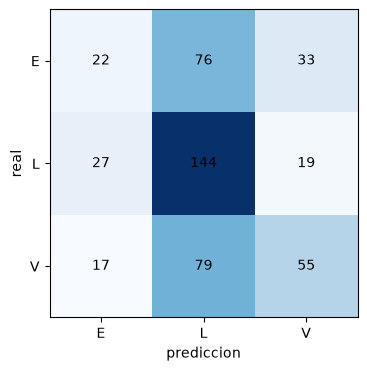

In [8]:
y_test = test['winner'].to_numpy()
y_pred = arbol_completo.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print('Macro-F1:', round(f1_score(y_test, y_pred, average='macro', zero_division=0), 4))
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

matrix = confusion_matrix(y_test, y_pred, labels=CLASSES)
fig, axis = plt.subplots(figsize=(5, 4))
image = axis.imshow(matrix, cmap='Blues')
axis.set_xticks(range(3), CLASSES)
axis.set_yticks(range(3), CLASSES)
axis.set_xlabel('prediccion')
axis.set_ylabel('real')
for row in range(3):
    for column in range(3):
        axis.text(column, row, str(matrix[row, column]), ha='center', va='center')
plt.show()

## 9. Ejemplos concretos: donde acierta y donde falla

Vemos partidos reales de test con la prediccion y el resultado. La columna `acierta` indica si ID3 acerto.

In [9]:
predicciones = test[['date', 'home', 'away', 'winner']].copy()
predicciones['prediccion_id3'] = y_pred
predicciones['acierta'] = predicciones['prediccion_id3'] == predicciones['winner']
display(predicciones.sample(8, random_state=RANDOM_STATE))
print('Aciertos totales:', int(predicciones['acierta'].sum()), '/', len(predicciones))

empates_reales = predicciones[predicciones['winner'] == 'E']
print('Sobre los', len(empates_reales), 'empates reales de test, '
      f'ID3 predijo exactamente empate en {(empates_reales["prediccion_id3"] == "E").sum()} '
      f'({(empates_reales["prediccion_id3"] == "E").mean():.1%}).')
display(empates_reales.head(3))

,date,home,away,winner,prediccion_id3,acierta
55,2024-04-13,CA Cerro,CA Fenix,E,L,False
73,2024-04-27,Rampla Juniors Futbol Club,Deportivo Maldonado,E,L,False
33,2024-03-23,Nacional,CA Progreso,E,L,False
278,2024-11-18,CA Progreso,CA Fenix,E,V,False
244,2024-10-20,Cerro Largo FC,Danubio,E,L,False
380,2025-04-13,Boston River,Cerro Largo FC,L,L,True
211,2024-09-29,Defensor Sporting,Deportivo Maldonado,L,L,True
9,2024-02-24,Montevideo Wanderers,Racing Club,V,E,False


Aciertos totales: 221 / 472
Sobre los 131 empates reales de test, ID3 predijo exactamente empate en 22 (16.8%).


,date,home,away,winner,prediccion_id3,acierta
3,2024-02-18,CA Cerro,Montevideo Wanderers,E,L,False
5,2024-02-18,Racing Club,Liverpool,E,V,False
8,2024-02-24,Boston River,Danubio,E,L,False


## 10. Efecto de podar con `min_info_gain`

Un arbol que crece demasiado memoriza ruido del train (sobreajuste). La opcion "podada" detiene la expansion cuando la ganancia no supera un umbral. Comparamos la eficacia de ambas versiones.

In [10]:
configuraciones = [
    ('ID3 completa (gain=0.0)', ID3(min_info_gain=0.0)),
    ('ID3 podada (gain=0.02)', ID3(min_info_gain=0.02)),
]

comparativa = []
for nombre, modelo in configuraciones:
    modelo.fit(X_train, train['winner'])
    predicha = modelo.predict(X_test)
    comparativa.append({
        'modelo': nombre,
        'profundidad': modelo.get_depth(),
        'hojas': modelo.get_n_leaves(),
        'accuracy': round(accuracy_score(y_test, predicha), 4),
        'macro_f1': round(f1_score(y_test, predicha, average='macro', zero_division=0), 4),
    })
display(pd.DataFrame(comparativa))

,modelo,profundidad,hojas,accuracy,macro_f1
0,ID3 completa (gain=0.0),6,645,0.4682,0.4129
1,ID3 podada (gain=0.02),2,7,0.4831,0.3434


## 11. Comparacion con scikit-learn

Nuestro ID3 es categorico y multiway: exige discretizar y parte en tantas ramas como categorias. Compararlo con la caja de herramientas de scikit-learn permite ver cuanto de la diferencia es del algoritmo y cuanto de la representacion de los datos. Tres contrincantes:

- **sklearn DecisionTree (mismo input)**: un arbol de sklearn entrenado con el *mismo* input discretizado que recibe nuestro ID3 (`criterion='entropy'`). Aisla la diferencia entre implementaciones.
- **sklearn DecisionTree (tasas crudas)**: el mismo arbol pero sobre las tasas continuas. Puede hacer cortes binarios en cualquier umbral, sin perder la precision de la tasa original como hace la discretizacion en 3 bines.
- **sklearn RandomForest (tasas crudas)**: bosque de 300 arboles con `class_weight='balanced_subsample'`, que re-muestrea cada arbol para equilibrar las clases. Representante de metodos modernos para comparar. 

Nota: RandomForest agrega 300 arboles; su profundidad y cantidad de hojas son por-arbol y por eso quedan vacias en la tabla.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

X_train_raw = train[NUMERIC_FEATURES].to_numpy()
X_test_raw = test[NUMERIC_FEATURES].to_numpy()
y_train = train['winner'].to_numpy()

competidores = {
    'sklearn DT (mismo input)': DecisionTreeClassifier(
        criterion='entropy', random_state=RANDOM_STATE
    ),
    'sklearn DT (tasas crudas)': DecisionTreeClassifier(
        criterion='entropy', random_state=RANDOM_STATE
    ),
    'sklearn RandomForest (crudo)': RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
    ),
}

filas = [
    {
        'modelo': 'ID3 propio (discretizado)',
        'input': '3 categorias',
        'profundidad': arbol_completo.get_depth(),
        'hojas': arbol_completo.get_n_leaves(),
        'accuracy': round(accuracy_score(y_test, y_pred), 4),
        'macro_f1': round(
            f1_score(y_test, y_pred, average='macro', zero_division=0), 4
        ),
    }
]

for nombre, modelo in competidores.items():
    usa_codigos = 'mismo input' in nombre
    X_entrena = X_train if usa_codigos else X_train_raw
    X_prueba = X_test if usa_codigos else X_test_raw
    modelo.fit(X_entrena, y_train)
    predicha = modelo.predict(X_prueba)
    filas.append(
        {
            'modelo': nombre,
            'input': '3 categorias' if usa_codigos else 'tasas crudas',
            'profundidad': (modelo.get_depth()
            if hasattr(modelo, 'get_depth') else None),
            'hojas': (modelo.get_n_leaves()
          if hasattr(modelo, 'get_n_leaves') else None),
            'accuracy': round(accuracy_score(y_test, predicha), 4),
            'macro_f1': round(
                f1_score(y_test, predicha, average='macro', zero_division=0), 4
            ),
        }
    )

display(pd.DataFrame(filas))

,modelo,input,profundidad,hojas,accuracy,macro_f1
0,ID3 propio (discretizado),3 categorias,6.0,645.0,0.4682,0.4129
1,sklearn DT (mismo input),3 categorias,12.0,637.0,0.4682,0.4131
2,sklearn DT (tasas crudas),tasas crudas,41.0,5983.0,0.4153,0.4037
3,sklearn RandomForest (crudo),tasas crudas,NaN,NaN,0.4407,0.4111


## 12. Efectividad del algoritmo

Para interpretar los numeros hay que compararlos con un **baseline trivial**: predecir siempre la clase mayoritaria de test (`L`, el local). Tambien revisamos la distribucion de predicciones y el recall por clase.

In [12]:
baseline_trivial = float((test['winner'] == 'L').mean())
print('Accuracy de predecir siempre L:', round(baseline_trivial, 4))
print('Accuracy del ID3 (gain=0.0):', round(accuracy_score(y_test, y_pred), 4))
print('\nDistribucion de predicciones del ID3 en test:')
display(
    pd.Series(y_pred)
    .value_counts()
    .reindex(CLASSES)
    .rename('predicciones')
    .to_frame()
)

reporte = classification_report(
    y_test, y_pred, output_dict=True, zero_division=0
)
print('Precision/Recall/F1 por clase:')
for clase in CLASSES:
    valor = reporte[clase]
    print(f'  {clase}: precision={valor["precision"]:.3f} '
          f'recall={valor["recall"]:.3f} f1={valor["f1-score"]:.3f}')

Accuracy de predecir siempre L: 0.4025
Accuracy del ID3 (gain=0.0): 0.4682

Distribucion de predicciones del ID3 en test:


,predicciones
E,66
L,299
V,107


Precision/Recall/F1 por clase:
  E: precision=0.333 recall=0.168 f1=0.223
  L: precision=0.482 recall=0.758 f1=0.589
  V: precision=0.514 recall=0.364 f1=0.426


### Como leer estos numeros

Dos preguntas: **funciona?** y **por que no rinde mas?**

**1. Supera al azar y al baseline.** Tres clases implican ~33% al azar; predecir siempre `L` da ~40% (la clase local es mayoritaria). Un accuracy de ~47-48% supera ambos, y el ID3 ademas captura victorias visitantes, cosa que el baseline trivial no hace.

**2. La clase `E` (empate) es casi imposible de separar.** Los empates son ~27-28% de los datos y su recall ronda el 17-18%. Una razon estructural: los atributos son tasas de victoria, que por construccion **no discriminan empates**; un equipo con forma excelente sigue empatando en la realidad. ID3 gasta la ganancia en separar `L` y `V`, y los empates quedan como ruido dentro de cada hoja (predice el minimo riesgo, casi nunca `E`).

**3. Greedy y categorias comprimen informacion.** ID3 elige atributo por atributo sin mirar combinaciones, y discretizar en 3 bines pierde la precision de la tasa original (p. ej. separa "2 de 5" de "3 de 5" pero no 0.40 de 0.45). Para este problema, donde cada partido tiene mucho ruido, el arbol logra un macro-F1 ~0.41 que es respetable pero revela el techo de los atributos.

**4. Poda: no siempre gana.** La poda (gain=0.02) simplifica el arbol (de ~645 hojas a 7) y a veces sube el accuracy pero **baja el macro-F1** porque deja de predecir clases minoritarias: gana en los partidos faciles, pierde el balance por clase. Con `min_info_gain` controlamos ese tradeoff, no hay un ganador universal.

## 13. Pendientes para el informe

- Registrar versiones de paquetes (sklearn, numpy, pandas).
- Incluir la tabla de ganancia de la seccion 6 como evidencia de como decide el arbol.
- Usar la matriz de confusion y el reporte por clase (no solo accuracy).
- Elegir 2-3 partidos de la seccion 9 para el analisis cualitativo.
- Discutir el techo de la clase `E` y la politica de imputacion neutra en limitaciones.
- Adaptar la declaracion de uso de IA del informe.

- Comparar nuestro ID3 con sklearn (mismo input, tasas crudas y RandomForest) en la tabla final.